<a href="https://colab.research.google.com/github/aman-5137/half_plasma/blob/main/_8_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/sample_data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [5]:
print('Current columns before dropping:', df.columns.tolist())

columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print('Missing values left :', df.isnull().sum().sum())
df.head()

Current columns before dropping: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Missing values left : 0


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [6]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y,  random_state=42)

print("Train: ", X_train.shape[0], "Test: ", X_test.shape[0])

Train:  712 Test:  179


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['died', 'survived']))

              precision    recall  f1-score   support

        died       0.84      0.88      0.86       110
    survived       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [11]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
y_pred = forest.predict(X_test)

print("Random forest = train accuracy: ", forest.score(X_train, y_train))
print("Random forest = test accuracy: ", forest.score(X_test, y_test))
print(classification_report(y_test, y_pred, target_names=['died', 'survived']))

Random forest = train accuracy:  0.9817415730337079
Random forest = test accuracy:  0.8156424581005587
              precision    recall  f1-score   support

        died       0.83      0.87      0.85       110
    survived       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



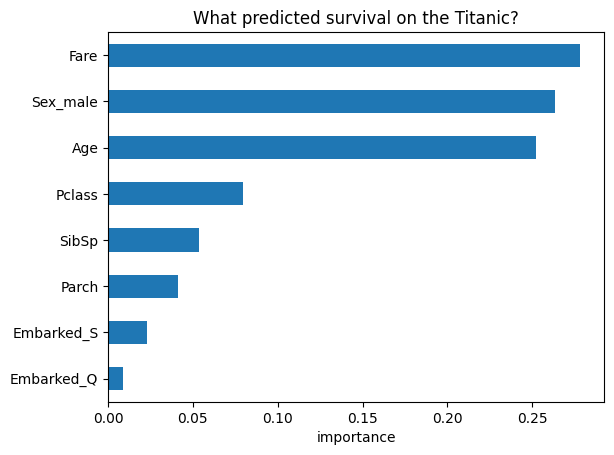

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract, label, and sort the feature importances
importances = pd.Series(
    forest.feature_importances_, index=X.columns
).sort_values()

# 2. Initialize the horizontal bar plot
importances.plot(kind="barh")

# 3. Add plot labels and title
plt.xlabel("importance")
plt.title("What predicted survival on the Titanic?")

# 4. Render the visualization
plt.show()
